In [3]:
import pandas as pd
import re

FF = pd.read_csv("FishFrys.csv")

# Which Neighborhoods Have The Most Fish Frys?
## A silly metric by Aaron Venham
![Good_Heavens](https://preview.redd.it/good-thats-one-less-loose-end-v0-zr4wxp1ips8g1.jpeg?width=1080&format=pjpg&auto=webp&s=35171d57423ea11f719044fb548e998e89920cb4)





## Why Fish Frys?
I chose Fish Frys as my metric simply because I thought the metric would be fun to explore. 

Using the data attained from the [WPRDC](https://data.wprdc.org/dataset/), I planned to extract the relevant data from the address lines. 


In [4]:
print('One such address:')
FF.iloc[155:156,[4]]

One such address:


,venue_address
155,"444 Jackson St, Monongahela, PA 15063"


With this plan, I began a cursory inspection on the address lines within the csv file itself and noted that there were a few West Virginia addresses. So my first step was to filter out these unwanted lines. I accomplished this by creating a list of patterns that looked for addresses that contained either 'PA' or 'Pennsylvania', then used these patterns to create a new data frame with only entries that were in the state of Pennsylvania. 

Code below:

In [5]:
#Patterns for string reading
STATEPATTERN = ['PA ','Pennsylvania ']

#creats a new data frame with only addresses in PA
FFZ = pd.DataFrame(FF[FF['venue_address'].str.contains('|'.join(STATEPATTERN))])

Next I extracted all the zip codes from the addresses and created a list from them. From this list, I created a dictonary of the zips and counted the occurrence of each one. Once done. a graph is created to visualize the data.

Code and Graph below:

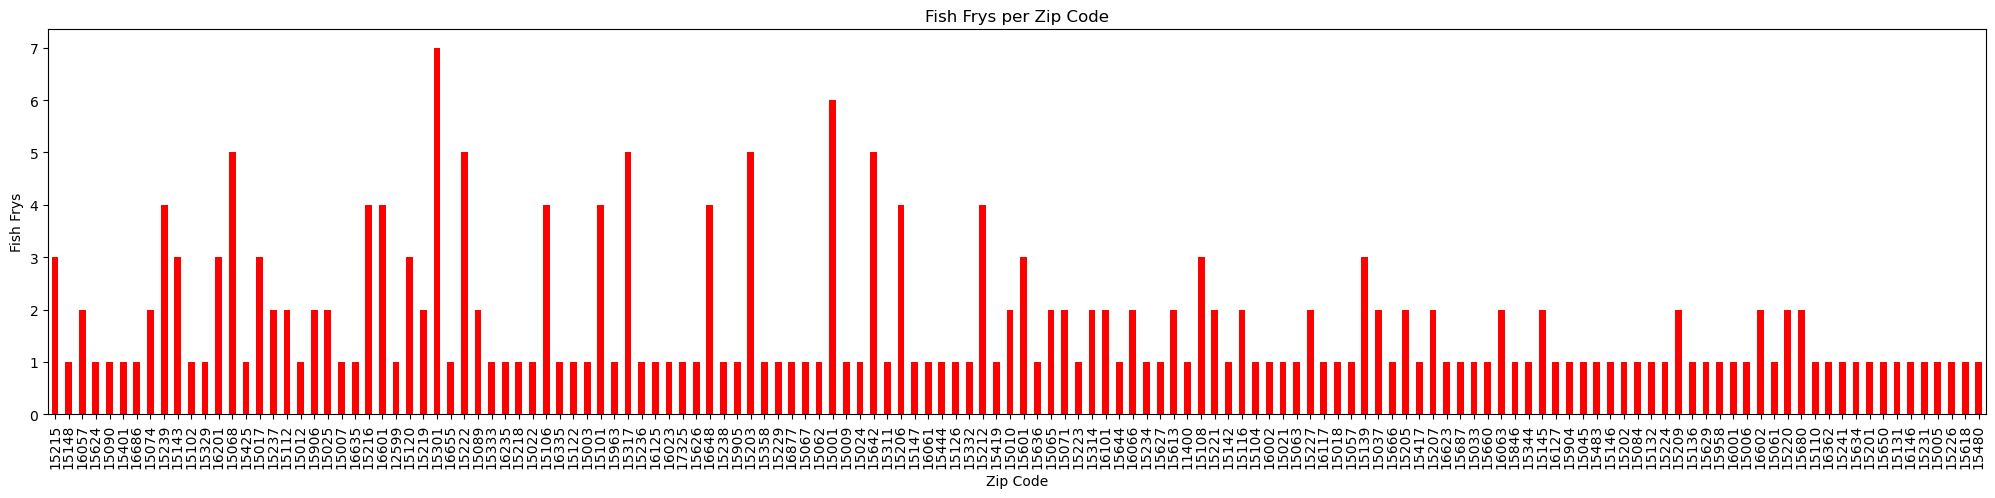

In [6]:
ZIPPATTERN = "\d{5}"

zipCodes = list(FFZ['venue_address'].str.findall(ZIPPATTERN))
zipDict = dict()
for code in zipCodes:
    if code[0] not in zipDict:
        zipDict[code[0]]=1
    else:
        zipDict[code[0]]=zipDict[code[0]]+1
#print(zipDict)
PerZip = pd.DataFrame.from_dict(zipDict,orient='index',columns=['Fish_Frys'])
TFF=PerZip['Fish_Frys'].sum()
WholeBarPlot = PerZip.plot.bar(title='Fish Frys per Zip Code',xlabel='Zip Code',ylabel='Fish Frys',figsize=(25,5),legend=False,color='red')

Now I found this graph to be a little too busy to read but at least shows that we have a complete data set to look at. 

To make this graph a little more readable, I squished the data to only show zip codes with more than 1 fish fry location.

Graph and Code below:

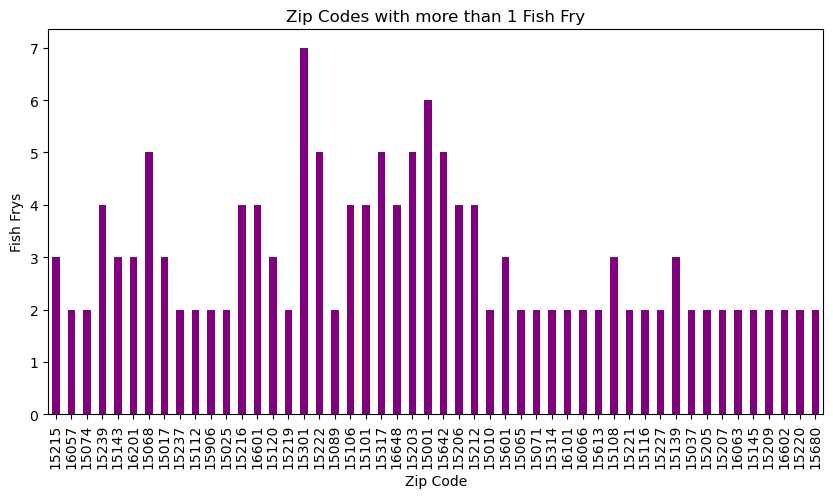

In [7]:
GrThOne = pd.DataFrame(PerZip).query('Fish_Frys > 1')
SquishedBarPlot = GrThOne.plot.bar(title='Zip Codes with more than 1 Fish Fry',xlabel='Zip Code',ylabel='Fish Frys',figsize=(10,5),legend=False,color='purple')

## **Perfect!**

Now we have a nice graph to look at and a nice set of data! 

Here is a nice list of the top 10 locations with the most Fish Frys:

In [8]:
GrThOne.nlargest(10,'Fish_Frys')

,Fish_Frys
15301,7
15001,6
15068,5
15222,5
15317,5
15203,5
15642,5
15239,4
15216,4
16601,4


With this data we can conclude that the zip code of **15301** is the best neighborhood to live in if you want an ample selection of places to grab some fried fish! 


# **Data Set Complete!**

![Thumbs_Up](https://i.imgflip.com/76tltl.png)


## Well... maybe not

A zip code is fine and all but that doesn't help us to know off the top of our head what city we are talking about. So with that in mind, I looked back at the data and extracted the city names from the addresses. This was an easy task as all I have to do is split up addresses on the '**,**' and insert these into a new data frame. **Easy!**

*Sadly not...*

This works great unless there is erroneous data in the address fields:

In [9]:
FFC = pd.DataFrame(FFZ['venue_address'].str.rsplit(',',n=3,expand=True))
FFC = FFC.rename(columns={0:'Street',1:'City',2:'State_Zip',3:'Country'})

#captures Erroneous data where city column contains a zip or is null
ErroneousNA = pd.DataFrame(FFC[FFC['City'].isna()])
Erroneous = pd.DataFrame(FFC[FFC['City'].notna()])
Erroneous = pd.DataFrame(Erroneous[Erroneous['City'].str.contains('|'.join(STATEPATTERN))])
ErroneousNA.head(30)

,Street,City,State_Zip,Country
40,1101 Old National Pike Fredericktown PA 15333,None,None,None
204,316 Railroad St. Stockdale PA 15483,None,None,None


In [10]:
Erroneous.head(30)

,Street,City,State_Zip,Country
11,25 Church Lane Prosperity,PA 15329,None,None
16,700 Bower Hill Road Bridgeville,PA 15017,None,None
29,3319 W. Liberty Ave. Pittsburgh,PA 15216,None,None
82,921 Amity Ridge Road Amity,PA 15311,None,None
97,1000 Wood Street,California PA 15419,None,None
126,605 Hewitt Ave. Washington,PA 15301,None,None
189,1818 Morningside Ave. Pittsburgh,PA 15206,None,None
199,192 11th Street Turtle Creek,PA 15145,None,None
250,10 Main Street Belle Vernon,PA 15680,None,None


But we have enough *clean* data, so we can ignore these data points and hold them to the side for now.

Lets fill a dictonary with all the proper cities we found using the same method as before and graph them:

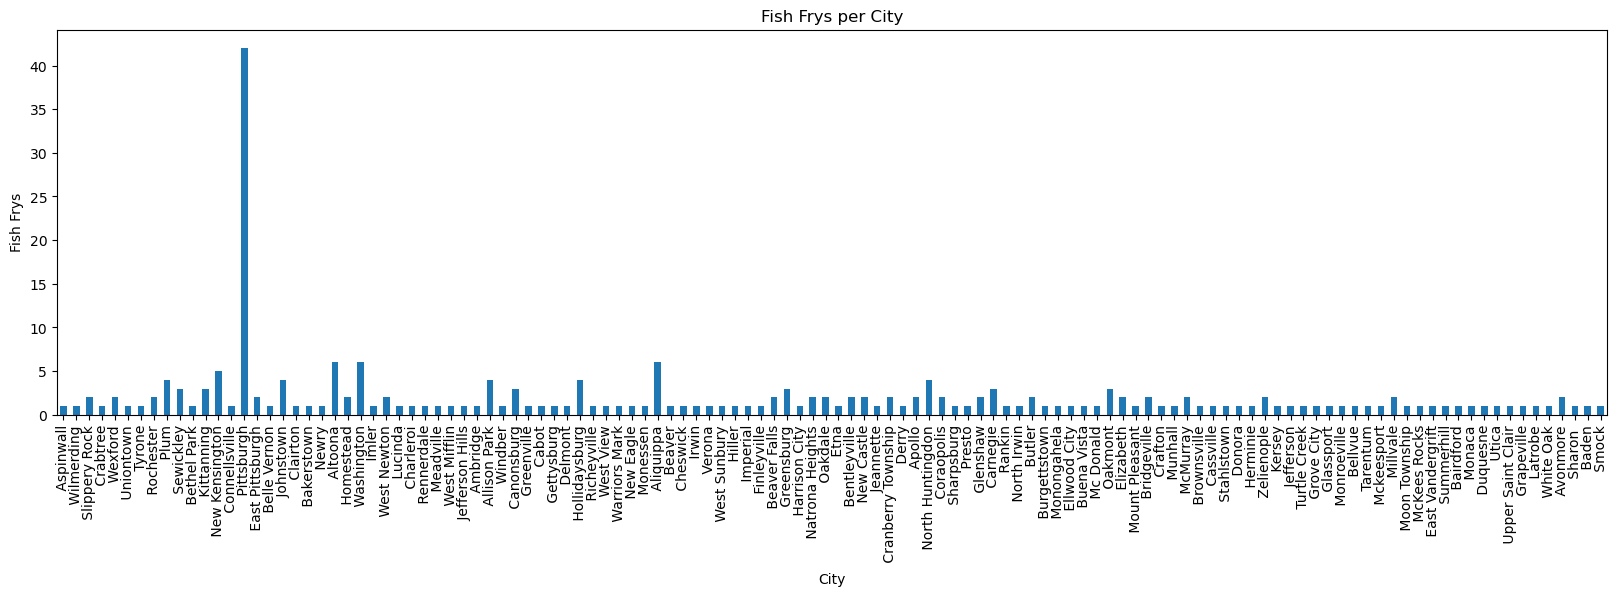

In [11]:
Cities = list(FFC['City'])
CityDict = dict()
for city in Cities:
    if city not in CityDict:
        if city!=None and not re.search(ZIPPATTERN, city):
            CityDict[city]=1
    else:
        CityDict[city]=CityDict[city]+1
#FF.query("venue_address.str.contains('Bethel Park')")
PerCity = pd.DataFrame.from_dict(CityDict,orient='index',columns=['Fish_Frys'])
CityBarPlot = PerCity.plot.bar(title='Fish Frys per City',xlabel='City',ylabel='Fish Frys',figsize=(20,5),legend=False)

## UH OH

Seems as though something has gone awry....

## This is fine!

If you want **ALOT** of options just live in Pittsburgh!

There are large proportion of addresses with just *Pittsburgh* as their city so this isn't as conclusive as you would think. So I dove into just the addresses with *Pittsburgh* as the city.

Once again we make a dictonary of **just** the zip codes *in* Pittsburgh and graphed them:

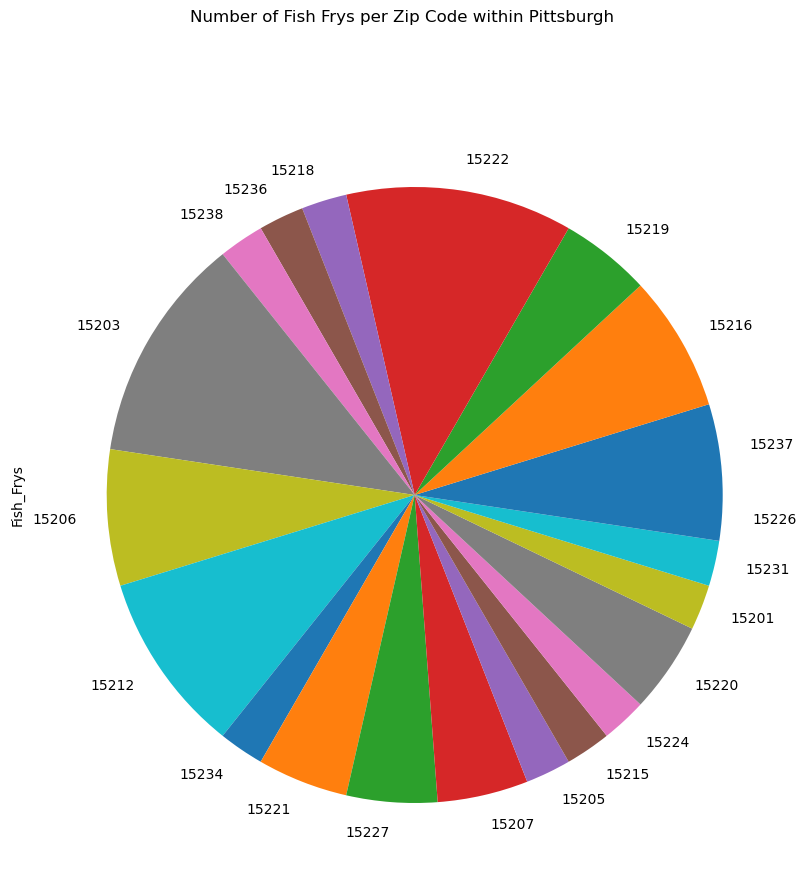

In [47]:
FFPitt = pd.DataFrame(FFC[FFC['City'].notna()])
FFPitt = pd.DataFrame(FFPitt[FFPitt['City'].str.contains('^ Pittsburgh')])
PittZip = list(FFPitt['State_Zip'].str.findall(ZIPPATTERN))
PitZipDict = dict()
for code in PittZip:
    if code[0] not in PitZipDict:
        PitZipDict[code[0]]=1
    else:
        PitZipDict[code[0]]=PitZipDict[code[0]]+1
ZipsOfPitt = pd.DataFrame.from_dict(PitZipDict,orient='index',columns=['Fish_Frys'])
PittPie = ZipsOfPitt.plot.pie(subplots=True,labeldistance=1.1,title="Number of Fish Frys per Zip Code within Pittsburgh",legend=False,figsize=(10,10))

![Pie](https://i.imgflip.com/fa1o7.jpg)
# The Pie Chart Amuses me


Now for a more serious graph:

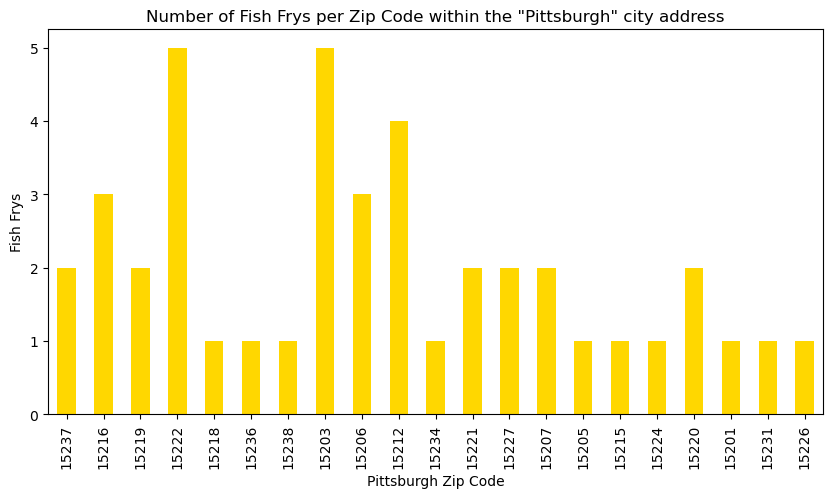

In [48]:
PittBarPlot = ZipsOfPitt.plot.bar(title='Number of Fish Frys per Zip Code within the "Pittsburgh" city address',xlabel='Pittsburgh Zip Code',ylabel='Fish Frys',figsize=(10,5),legend=False,color='gold')

Now we have a more accurate depiction of the true spread of Fish Frys within the city address of Pittsburgh!

Let's pull back out and look at the other cities now that we took out the Pittsburgh bar:

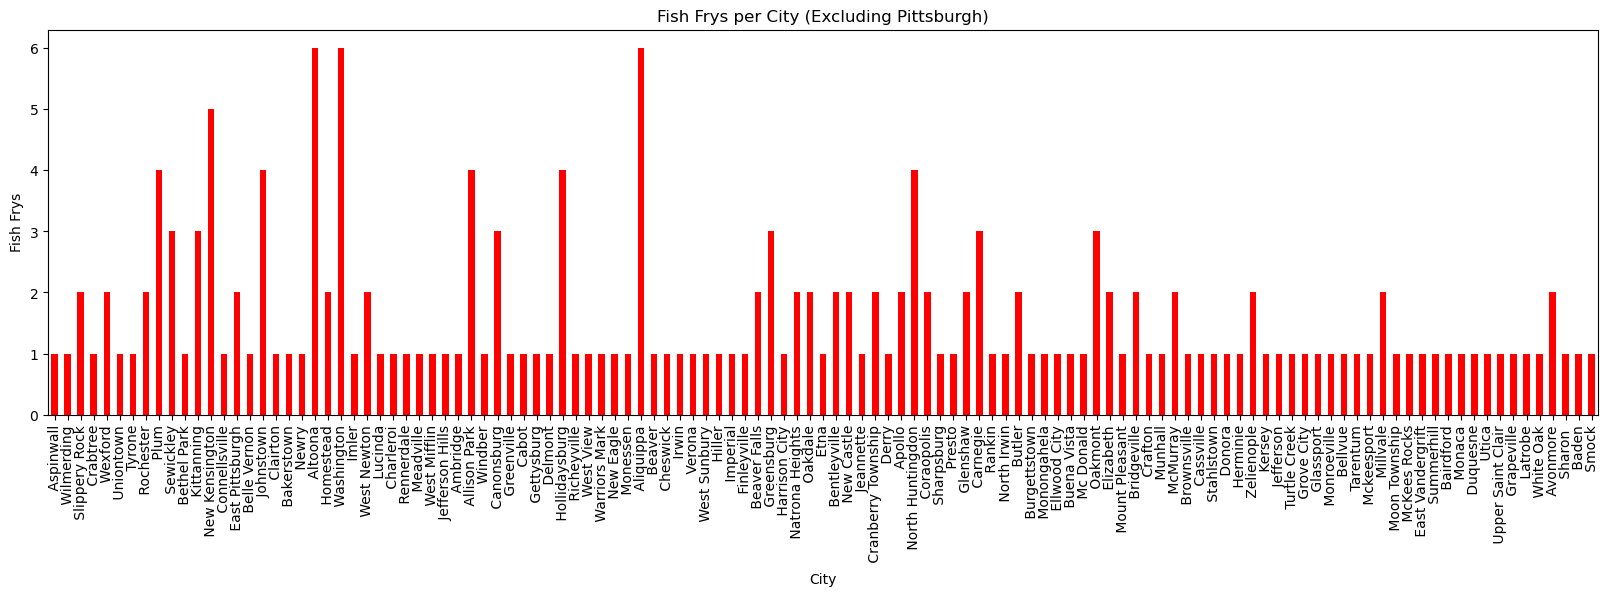

In [49]:
CityDict.pop(' Pittsburgh', None)
NoPitt = pd.DataFrame.from_dict(CityDict,orient='index',columns=['Fish_Frys'])
NoPittBarPlot = NoPitt.plot.bar(title='Fish Frys per City (Excluding Pittsburgh)',xlabel='City',ylabel='Fish Frys',figsize=(20,5),legend=False,color='red')

## Much nicer!

Now we have alot less whitespace.

We can squish this like before and just look at places with more than 1 fish fry:

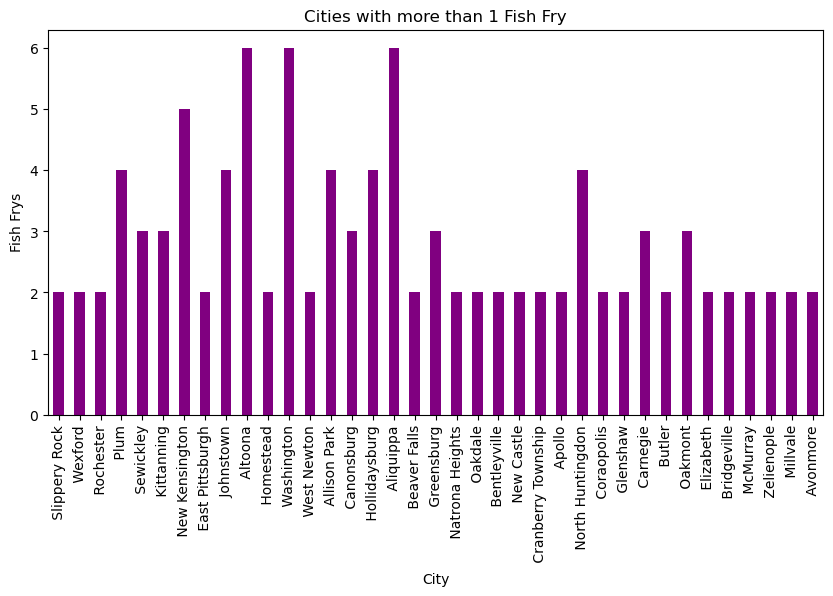

In [50]:
CitiesGrThOne = pd.DataFrame(NoPitt).query('Fish_Frys > 1')
CitiesSquishedBarPlot = CitiesGrThOne.plot.bar(title='Cities with more than 1 Fish Fry',xlabel='City',ylabel='Fish Frys',figsize=(10,5),legend=False,color='purple')

Now we can combined these two lists and see what the new spread is like!

In [51]:
MergedCities = pd.concat([NoPitt,ZipsOfPitt])
MergedCities.nlargest(10,'Fish_Frys')

,Fish_Frys
Altoona,6
Washington,6
Aliquippa,6
New Kensington,5
15222,5
15203,5
Plum,4
Johnstown,4
Allison Park,4
Hollidaysburg,4


# In conclusion

My personal favorite neighboorhood is **Oakdale** and I'm happy to see we made the squished graph, however I'm sad that we dont make the top 10. That honor belongs to the Cities listed above, most notably **Altoona**, **Washington** and **Aliquippa**. I wasn't sure what kinda result I would see but the disparity between how many Fish Frys were in Pittsburgh, without splitting it up, versus everywhere else was amusing and unexpected. I didnt realize how many addresses just simply had Pittsburgh as their city.